# SSID 9-class detector - Run C - 640 px, trained to convergence

Run B's settings carried to 150 epochs instead of 50, to find out whether that arm was simply still climbing when it ran out. It was: the best epoch moved from 50 to 120. This is the 640 px ceiling.

Model: YOLO11n | 50 epochs | imgsz 640 | batch 8 | seed fixed | RTX 3050 Laptop 4 GB

Dataset: 2,190 images (train 1,575 / val 400 / test 215), 22,957 boxes, 9 classes.
Every label row is a plain bounding box: the Roboflow export mixed bbox and polygon rows,
which Ultralytics mis-reads per file, so it was normalised with `polygons_to_bboxes.py`
first. Training a fresh export without that step corrupts thousands of boxes silently.

**No class rebalancing was applied.** `finger` really does carry 7,157 of the 16,421
training boxes; downsampling it would have deleted whole images, taking the other classes
in those frames with them. The imbalance is a property of the reported result, not a bug.


In [ ]:
from IPython.display import Image, display

## 1. Metrics

All figures are for this run only, at the default confidence threshold used by the validator.

| Metric | Validation Set | Test Set |
| --- | ---: | ---: |
| mAP@50 | 71.63% | 66.58% |
| Precision | 77.02% | 71.09% |
| Recall | 70.90% | 63.76% |
| F1 | 73.83% | 67.23% |
| mAP@50-95 | 43.66% | 40.79% |


## 2. Average precision by class (mAP@50)

| Class | Validation instances | Validation mAP@50 | Validation Precision | Validation Recall | Test instances | Test mAP@50 | Test Precision | Test Recall |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Stitch Scissors | 10 | 98.59% | 96.25% | 90.00% | 3 | 43.14% | 32.91% | 33.33% |
| Tip_needle_holder | 291 | 86.32% | 82.66% | 88.45% | 145 | 86.41% | 84.35% | 86.21% |
| Tip_forcep | 158 | 78.10% | 78.33% | 81.01% | 81 | 79.02% | 82.69% | 75.31% |
| finger | 1775 | 77.99% | 70.90% | 77.92% | 952 | 78.74% | 74.32% | 74.47% |
| needle_holder | 525 | 76.01% | 77.16% | 75.29% | 257 | 75.79% | 77.66% | 75.88% |
| forcep | 340 | 74.01% | 85.84% | 67.75% | 176 | 76.15% | 83.95% | 64.77% |
| hand | 364 | 62.95% | 60.11% | 84.47% | 181 | 65.16% | 65.30% | 91.16% |
| wound | 467 | 60.23% | 67.76% | 48.82% | 254 | 63.14% | 72.00% | 47.58% |
| needle | 366 | 30.47% | 74.19% | 24.35% | 191 | 31.63% | 66.67% | 25.13% |


**Per-class detection quality - validation set**


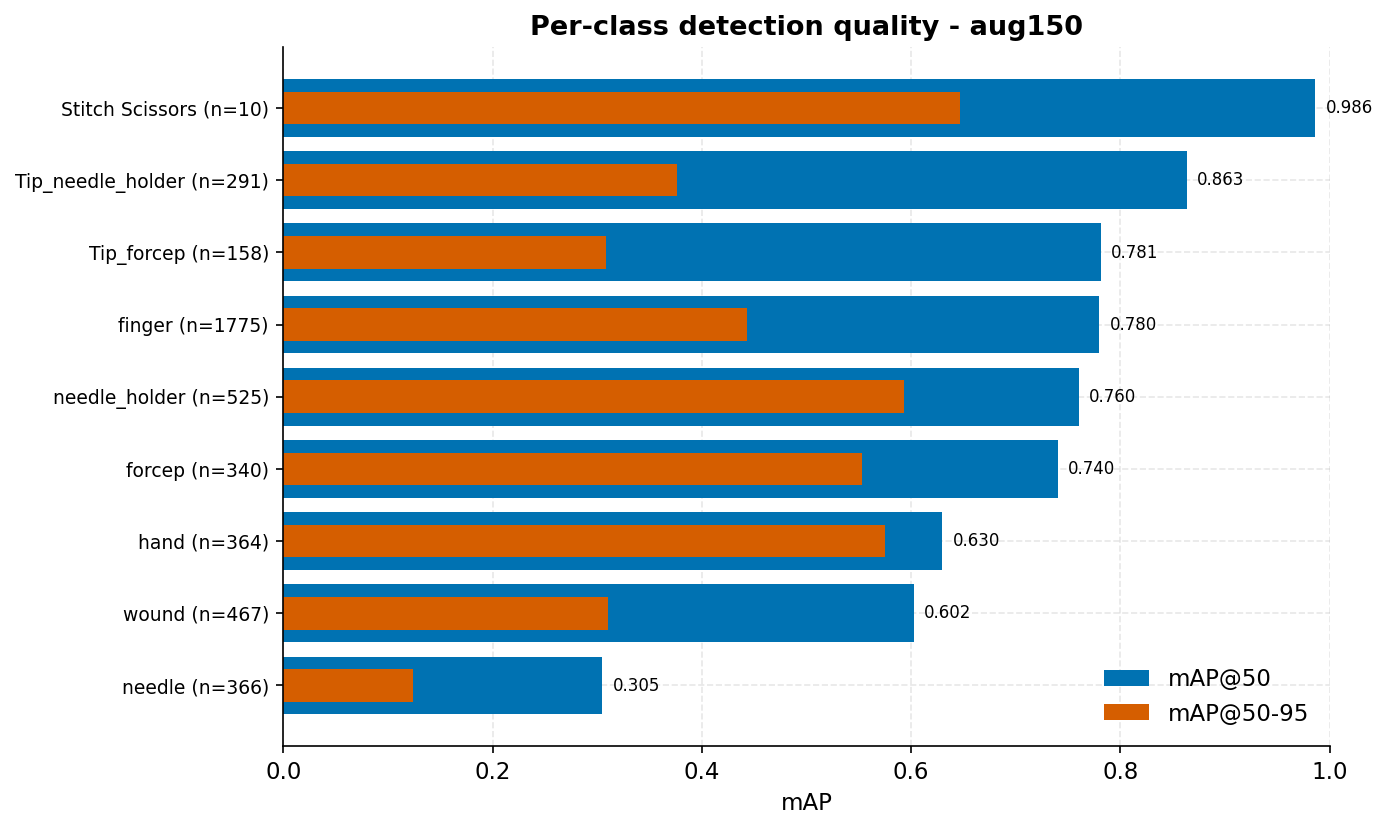

In [1]:
display(Image(filename='results_150/aug150_per_class_map50.png'))

**Per-class detection quality - test set**


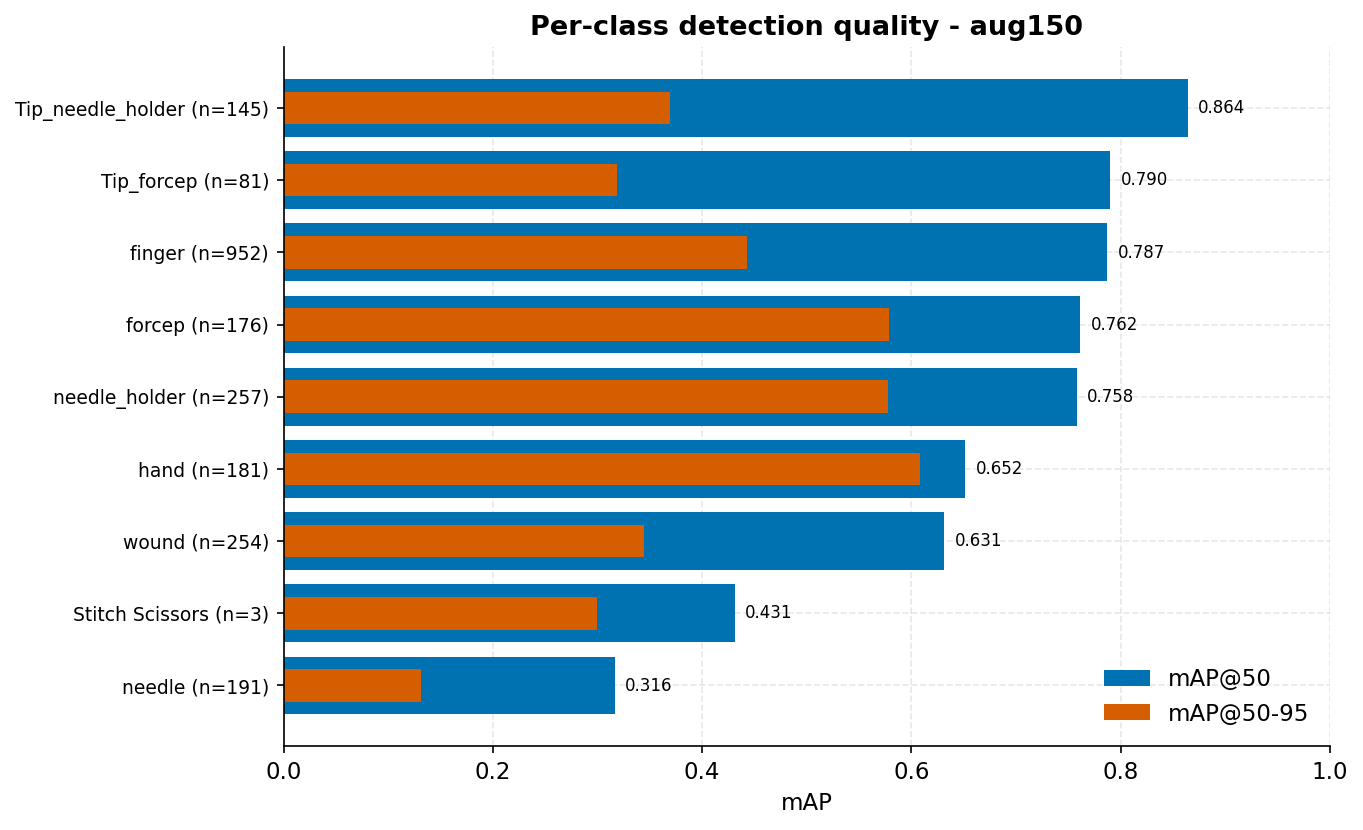

In [2]:
display(Image(filename='results_150_test/aug150_per_class_map50.png'))

## 3. Training graphs

YOLO11 optimises **three** losses. There is no objectness loss - that belonged to YOLOv5 and
v7; distribution focal loss (DFL) is what replaced it. Each component is plotted on its own
axes because `cls_loss` starts an order of magnitude above `box_loss` and flattens the
smaller curve when they share a scale.


**Box loss (localisation)**


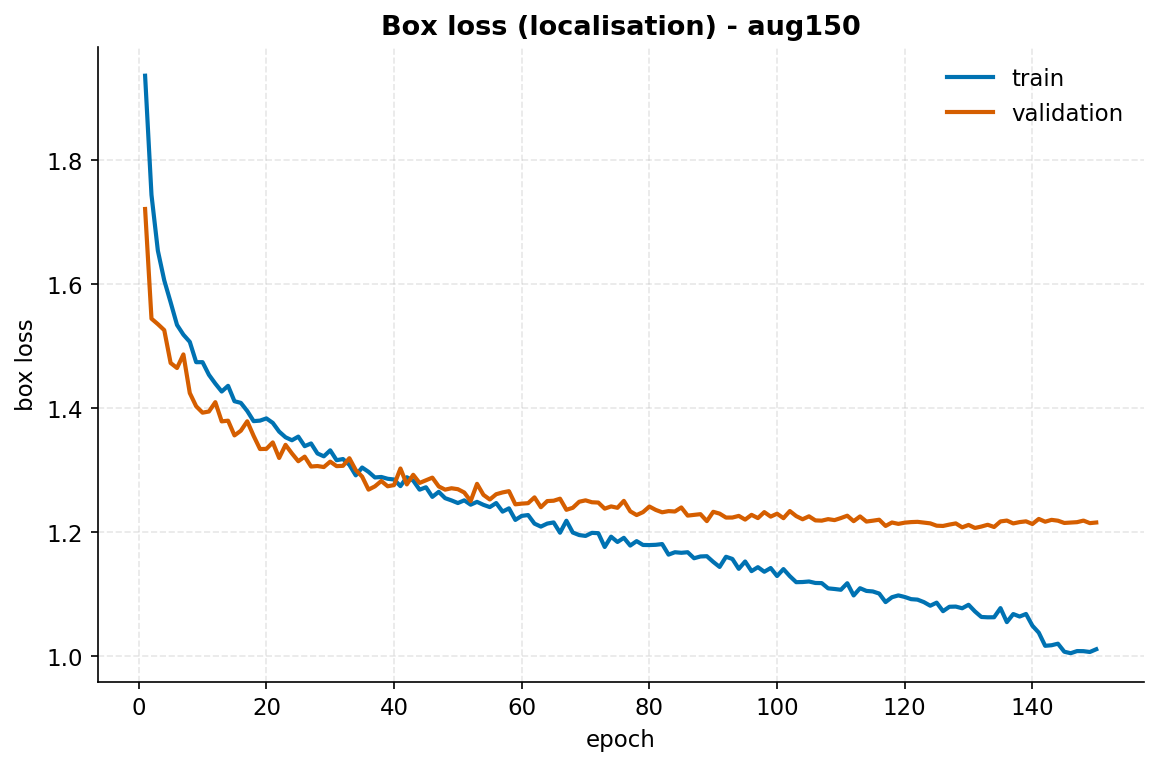

In [3]:
display(Image(filename='results_150/aug150_box_loss.png'))

**Class loss (classification)**


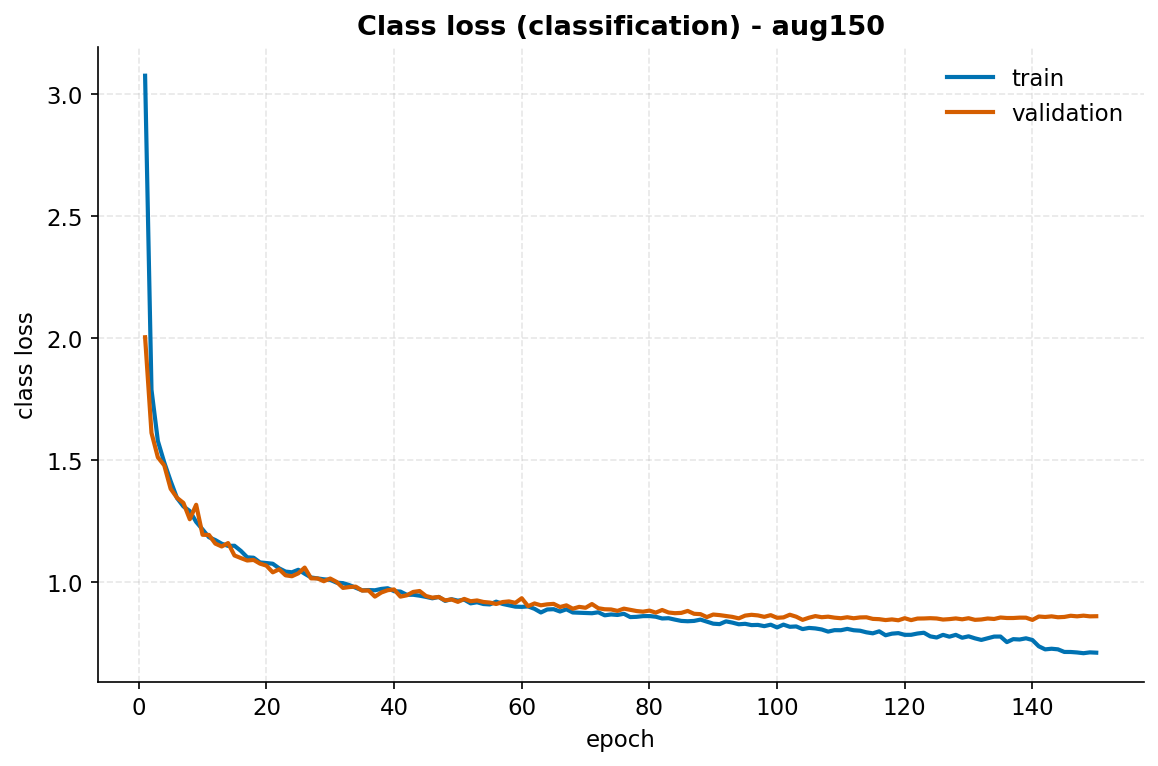

In [4]:
display(Image(filename='results_150/aug150_cls_loss.png'))

**DFL loss (replaces objectness)**


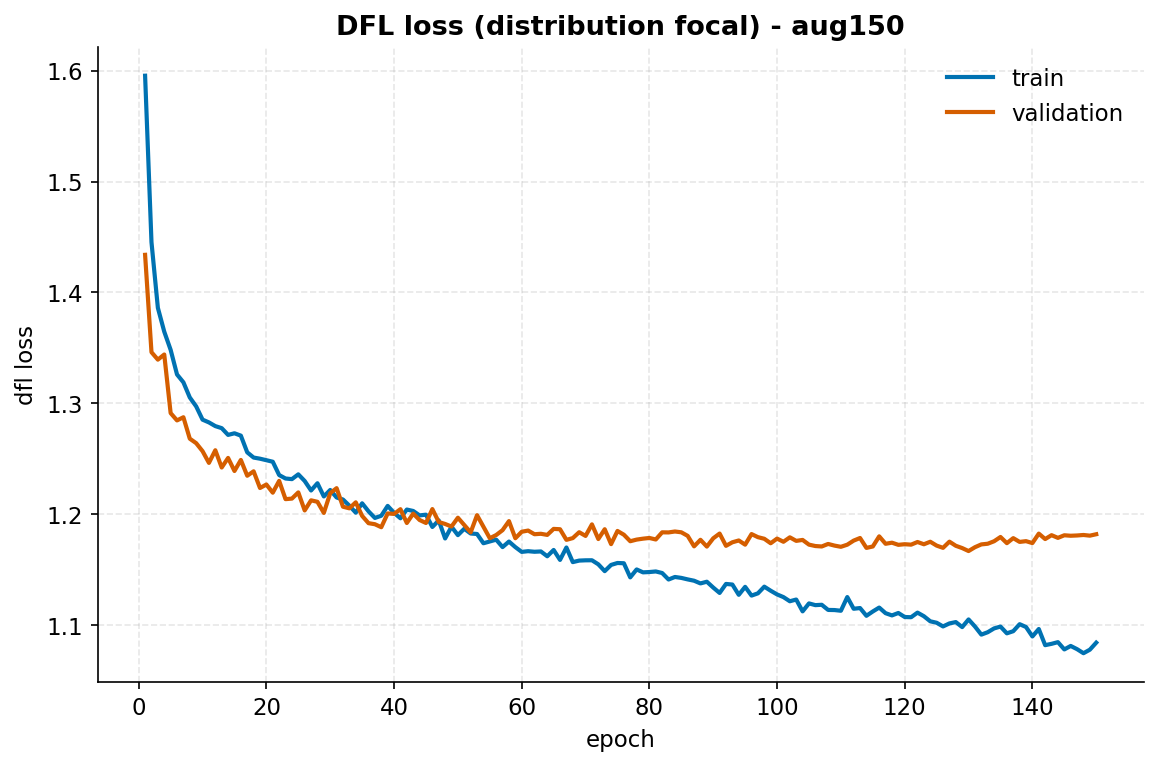

In [5]:
display(Image(filename='results_150/aug150_dfl_loss.png'))

**Total loss, train vs validation**


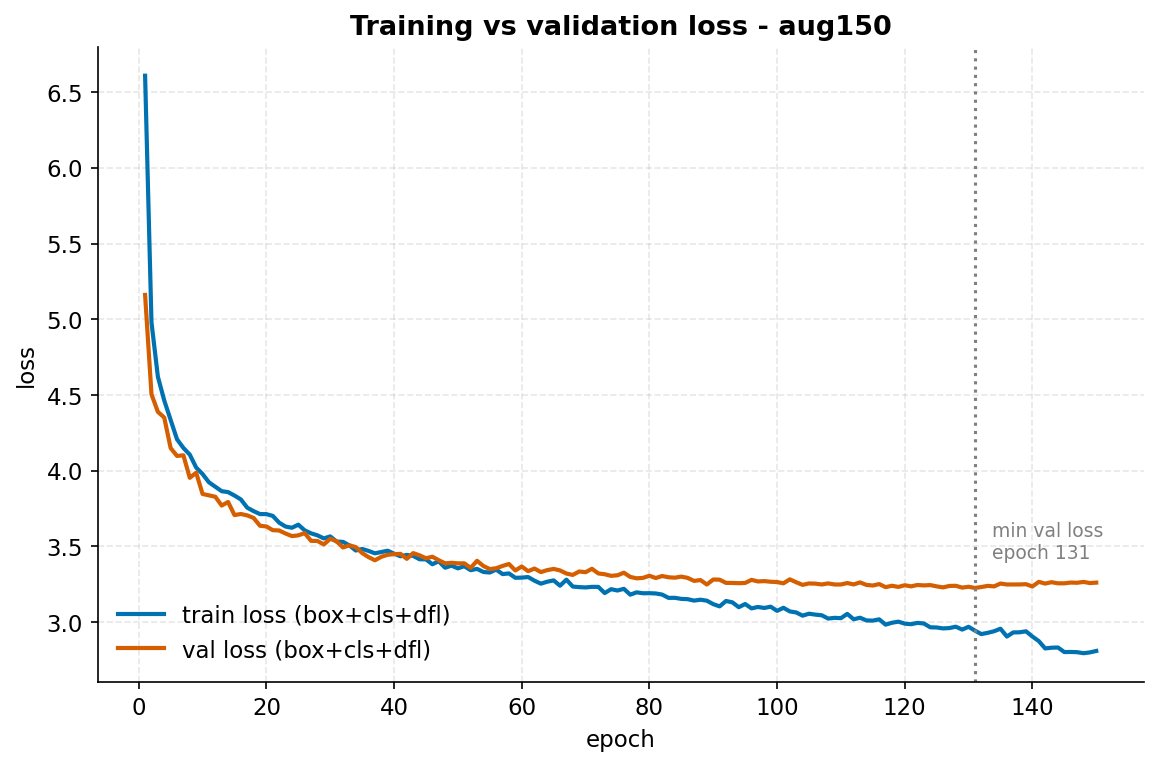

In [6]:
display(Image(filename='results_150/aug150_loss_curve.png'))

**mAP per epoch**


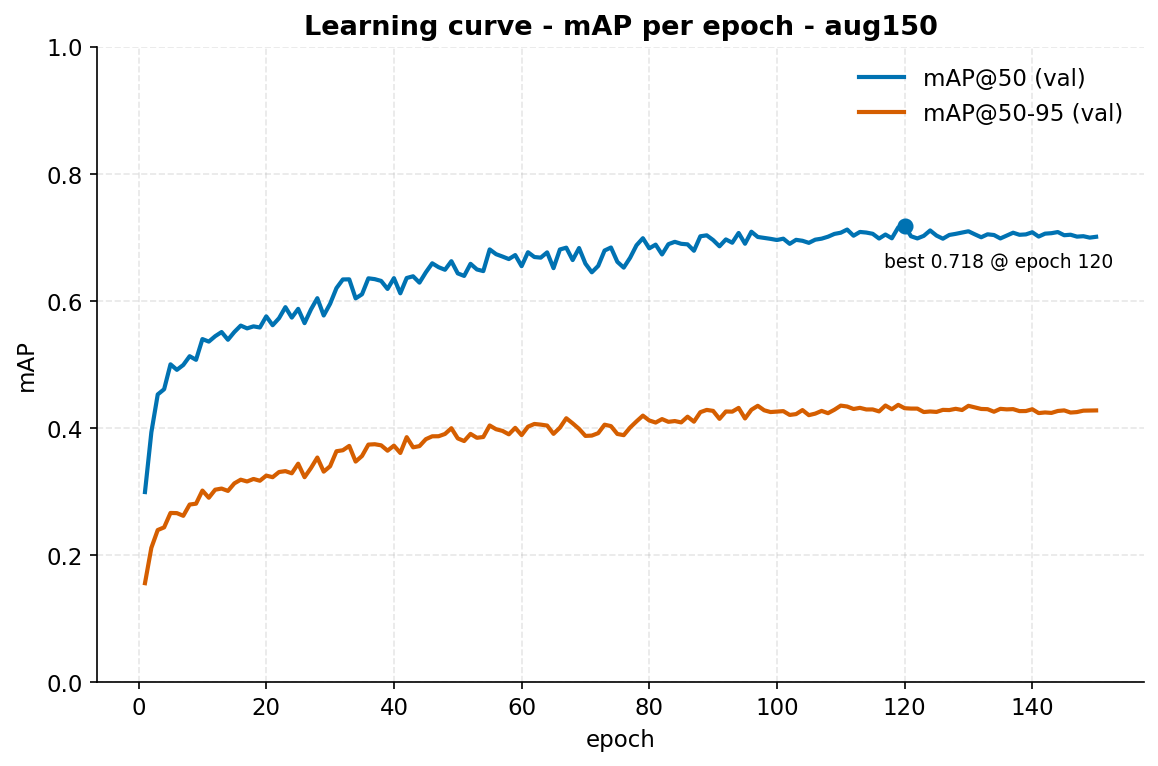

In [7]:
display(Image(filename='results_150/aug150_learning_curve_map.png'))

**Precision and recall per epoch**


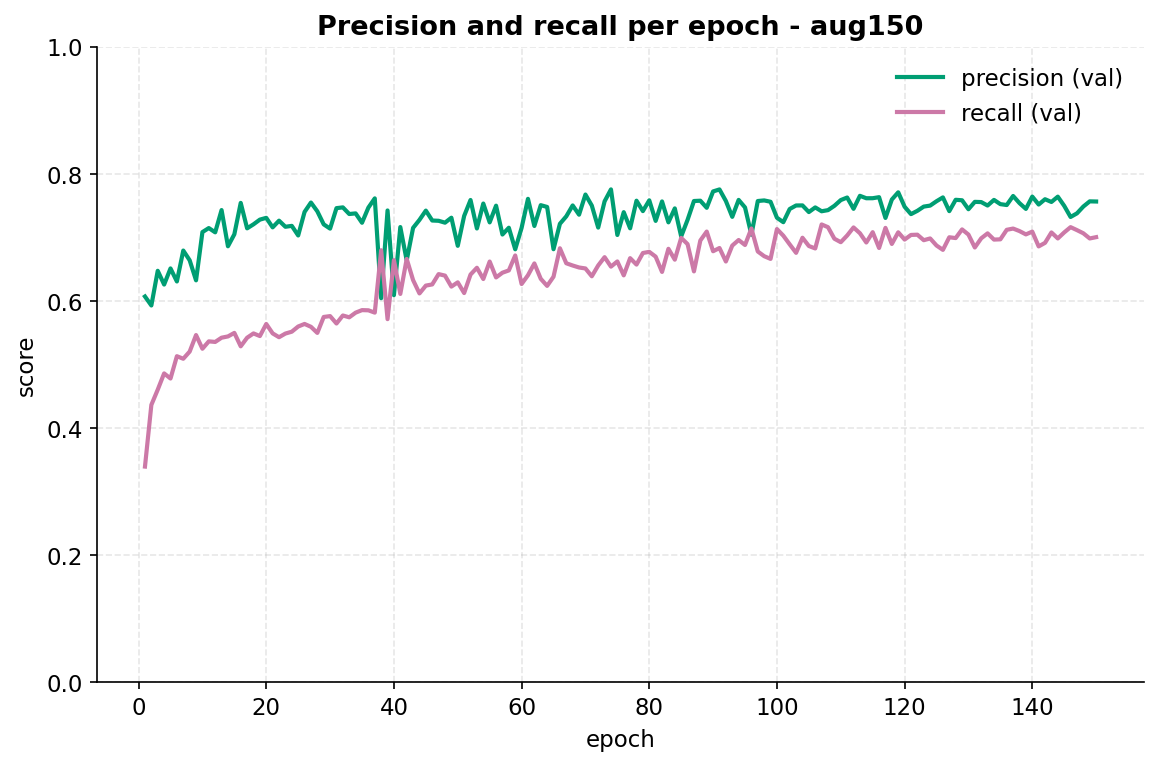

In [8]:
display(Image(filename='results_150/aug150_precision_recall_per_epoch.png'))

**Learning rate schedule**


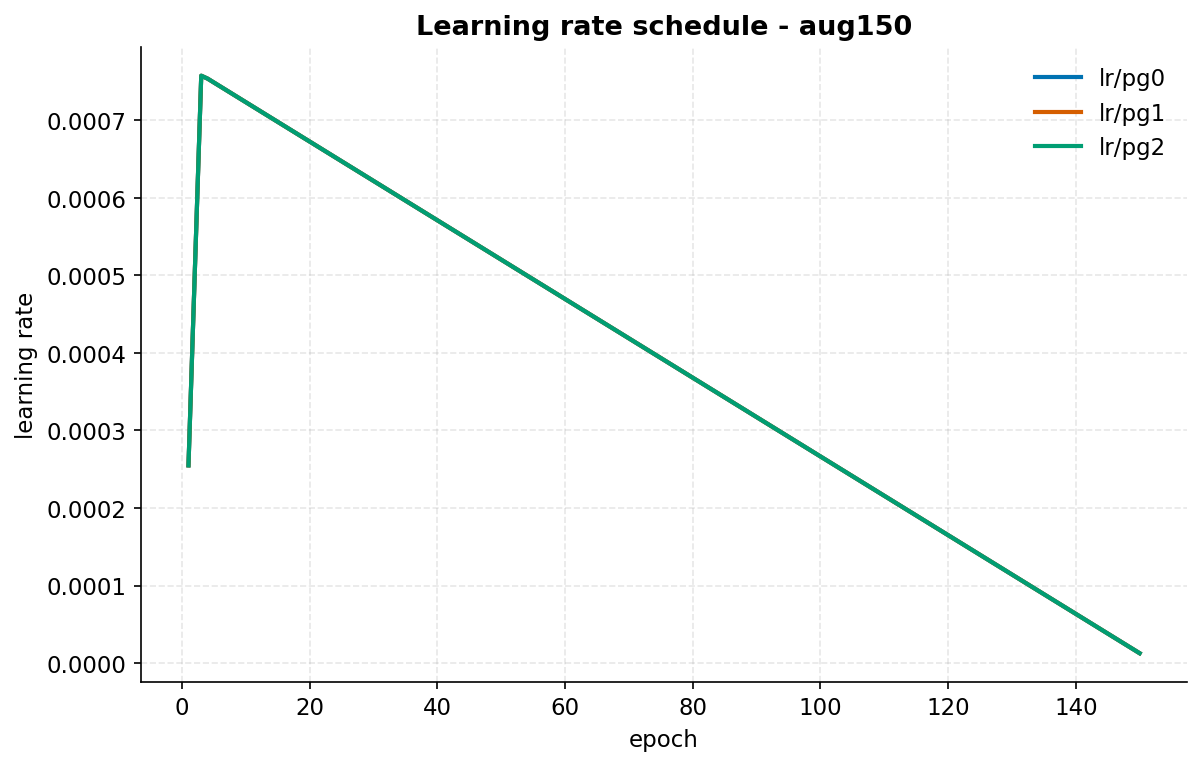

In [9]:
display(Image(filename='results_150/aug150_lr_schedule.png'))

## 4. Confusion matrix

Columns are the true class, rows are what the model predicted, and the extra `background`
row/column is the one that matters most: the background **row** counts detections that
matched no object (false positives), and the background **column** counts real objects the
model missed entirely (false negatives). Normalisation is per true class, so each column
reads as "of all the real X in this split, what did the model call them?"


**Confusion matrix, normalised per true class - validation set**


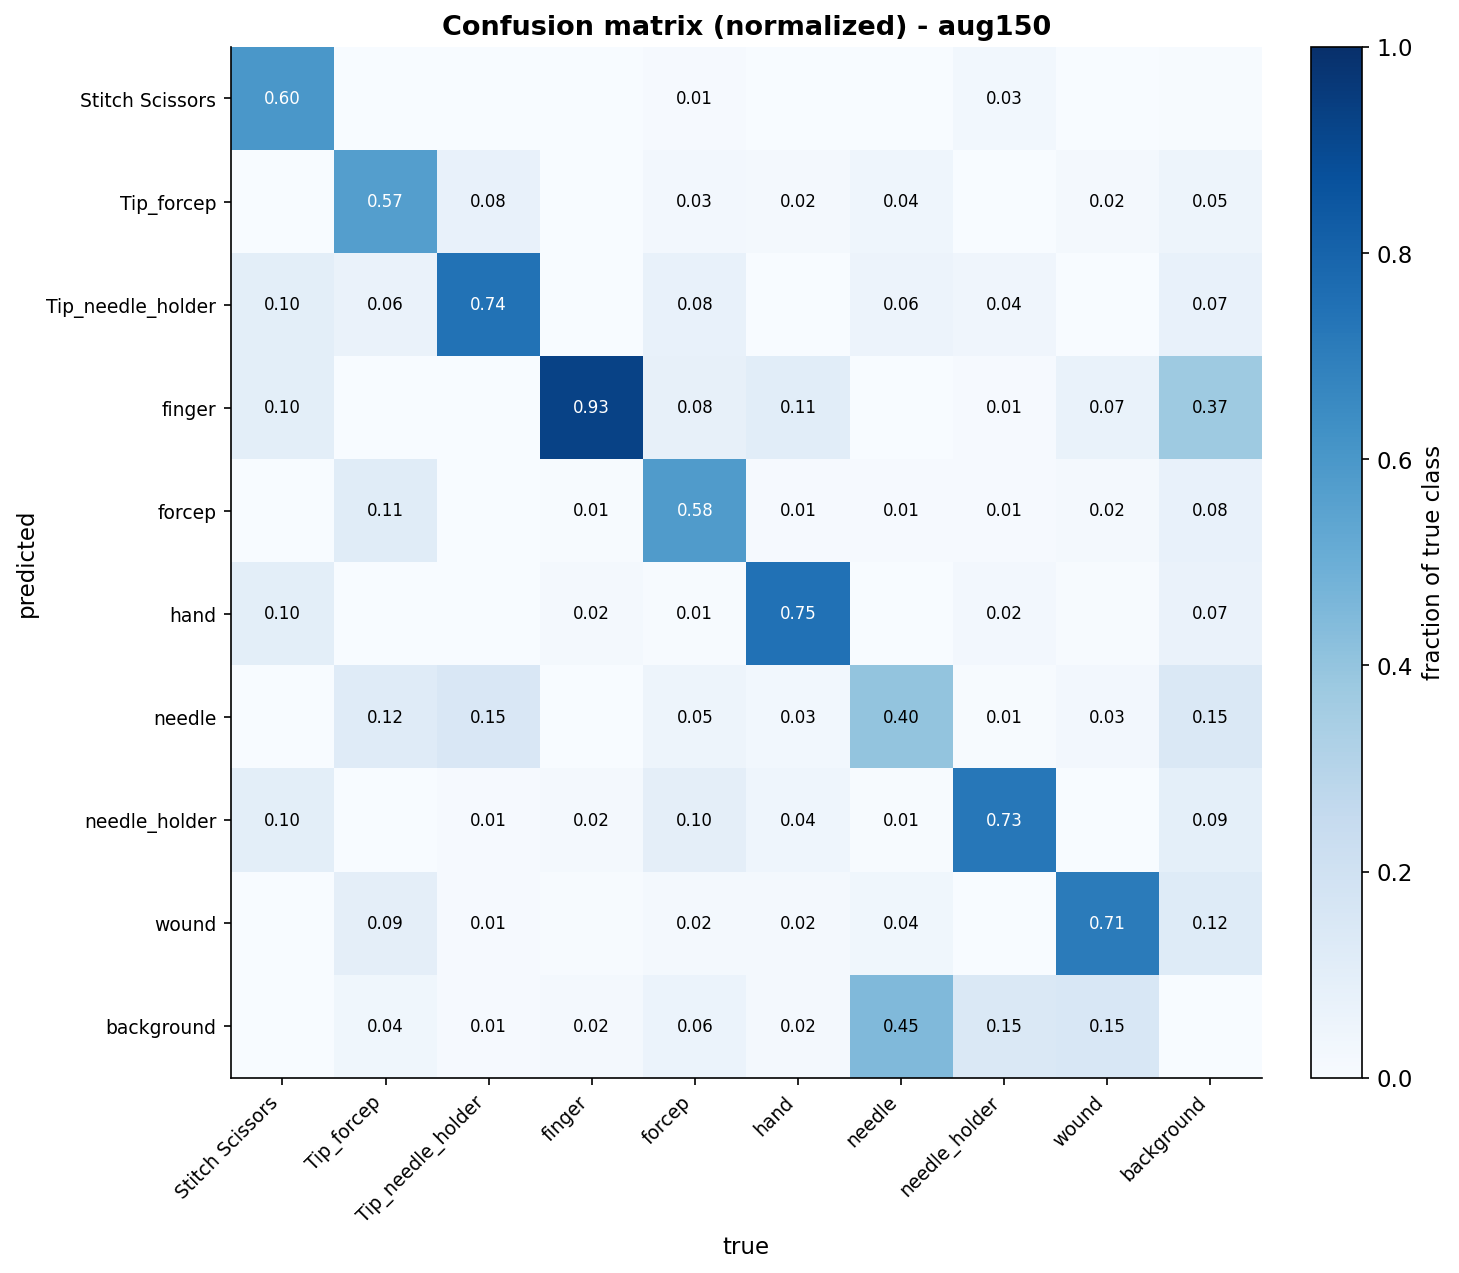

In [10]:
display(Image(filename='results_150/aug150_confusion_matrix_normalized.png'))

**Confusion matrix, raw counts - validation set**


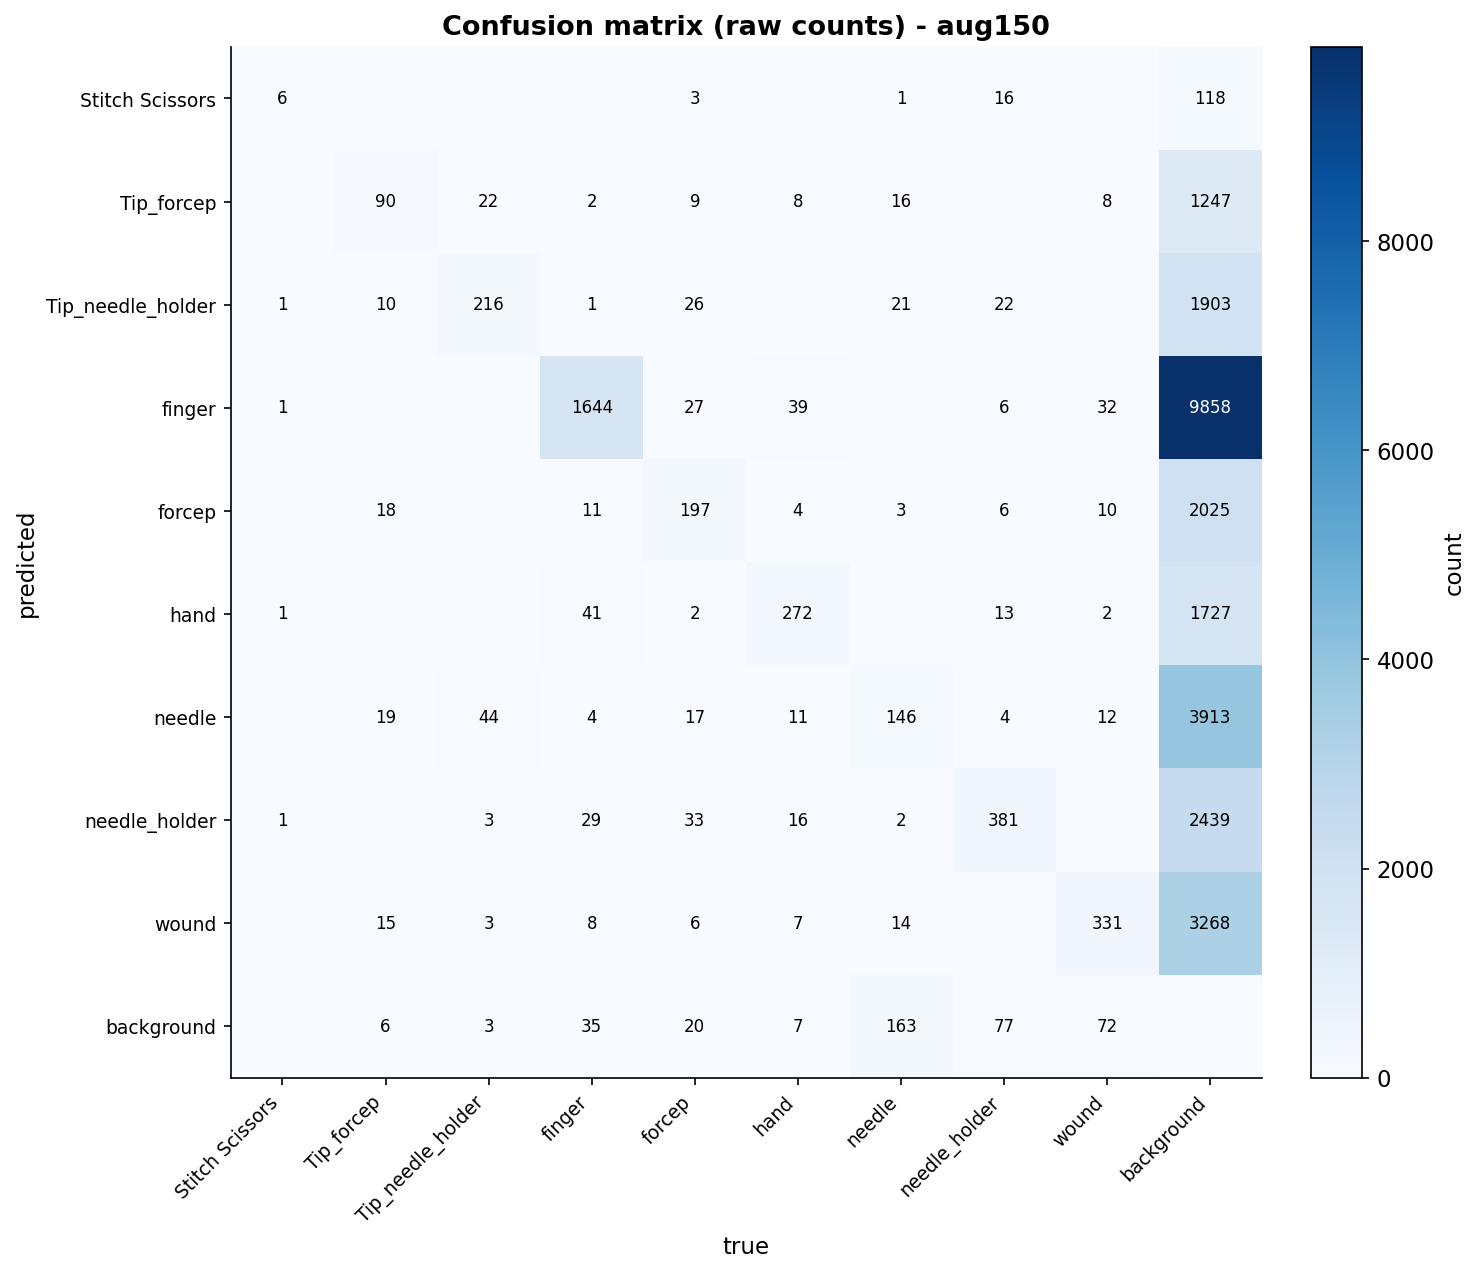

In [11]:
display(Image(filename='results_150/aug150_confusion_matrix_raw.png'))

**Confusion matrix, normalised per true class - test set**


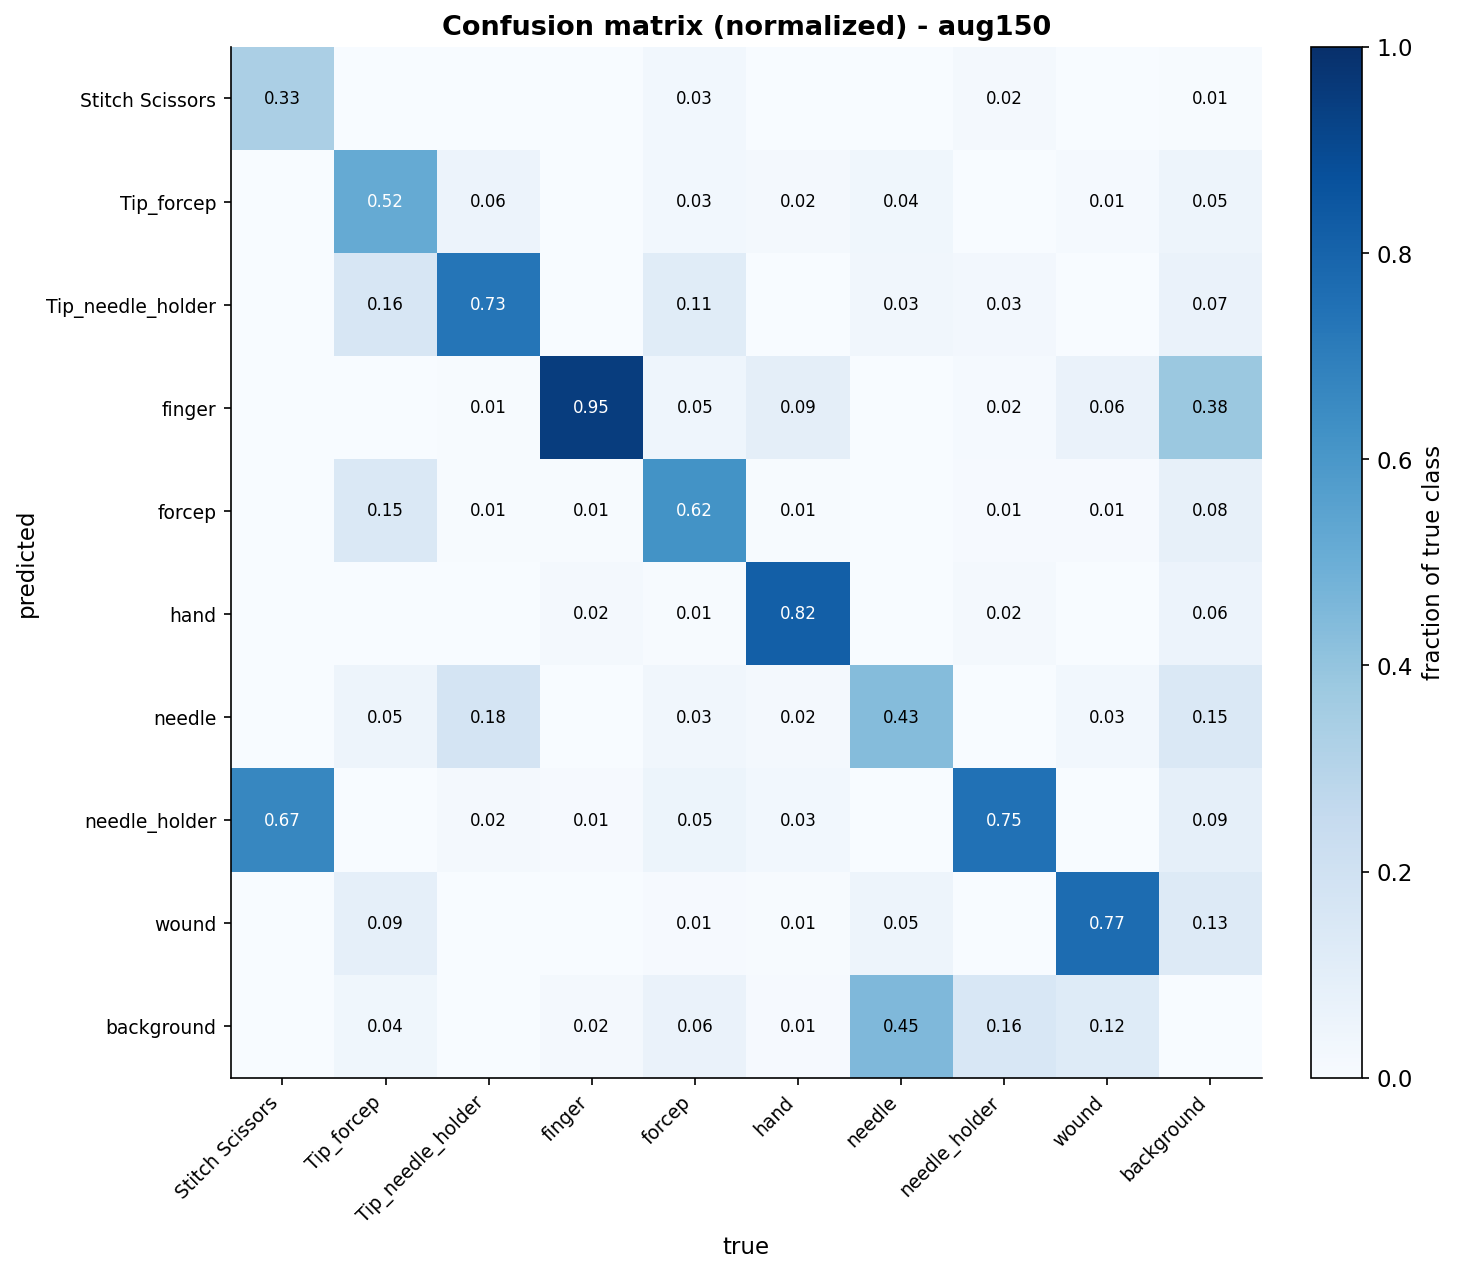

In [12]:
display(Image(filename='results_150_test/aug150_confusion_matrix_normalized.png'))

## 5. Threshold behaviour

How precision, recall and F1 move as the confidence threshold changes - the curves to consult before picking an operating point.


**Precision-recall per class**


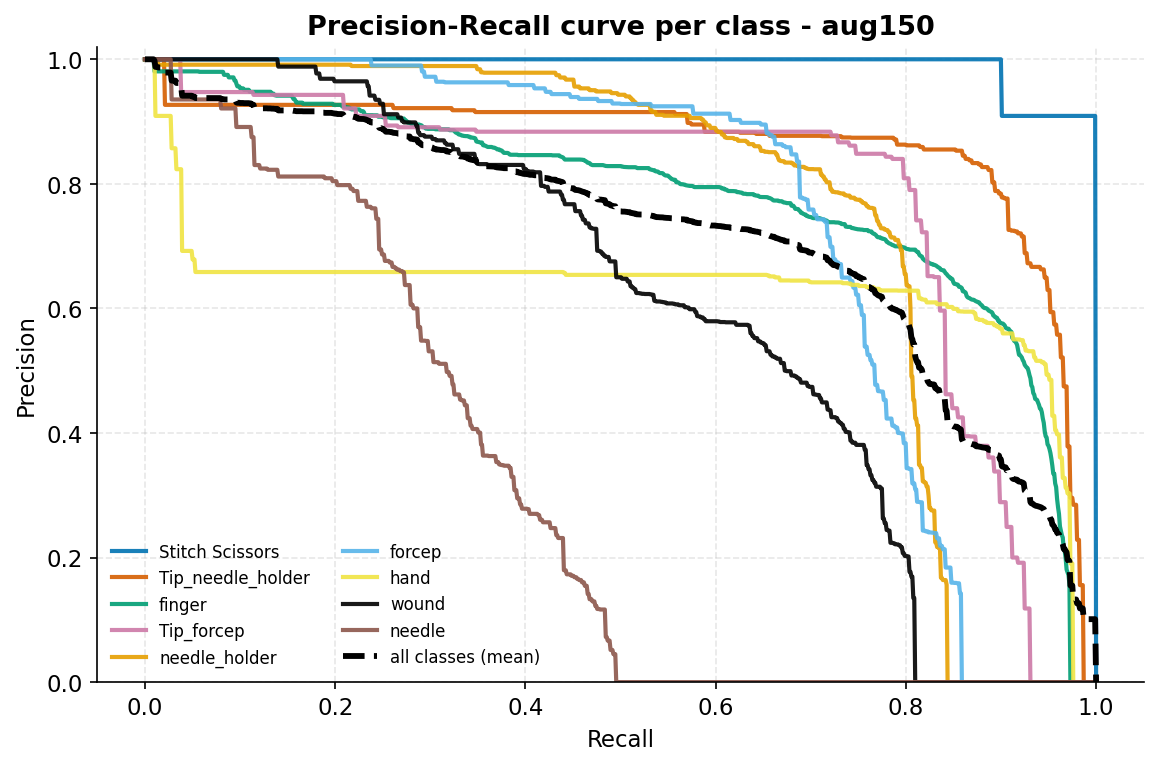

In [13]:
display(Image(filename='results_150/aug150_pr_curve_per_class.png'))

**F1 vs confidence**


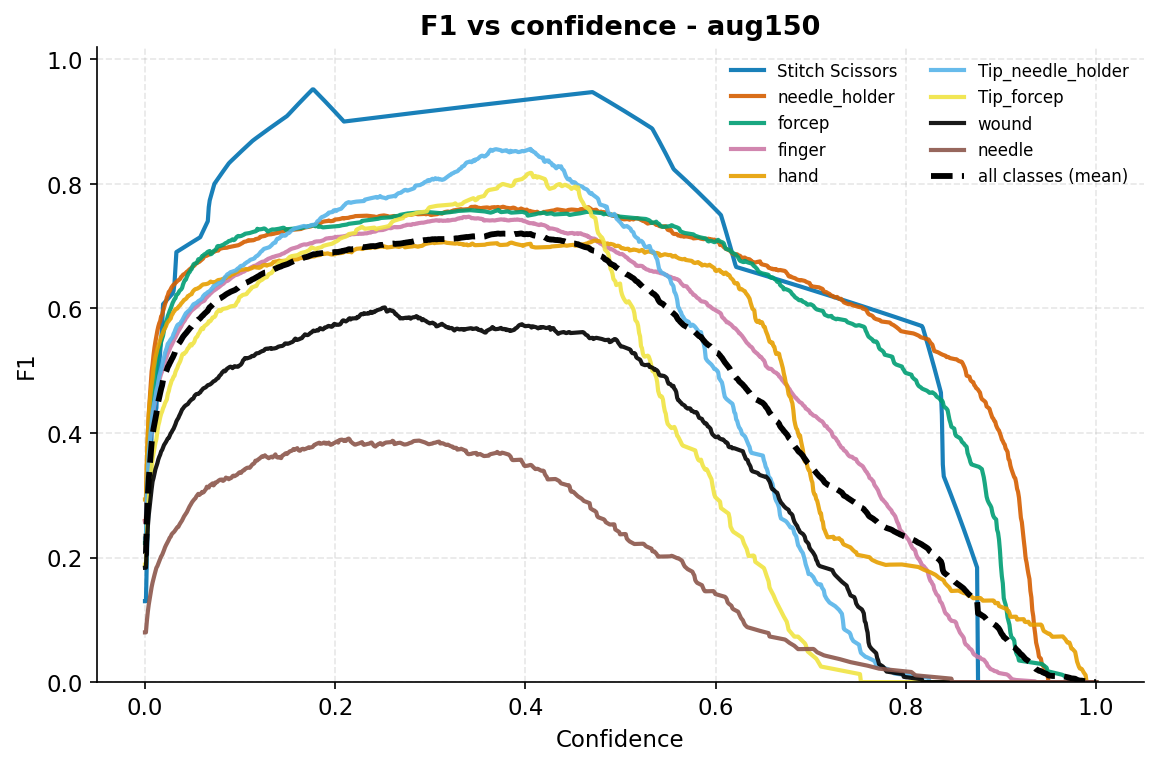

In [14]:
display(Image(filename='results_150/aug150_f1_confidence_curve.png'))

**Precision vs confidence**


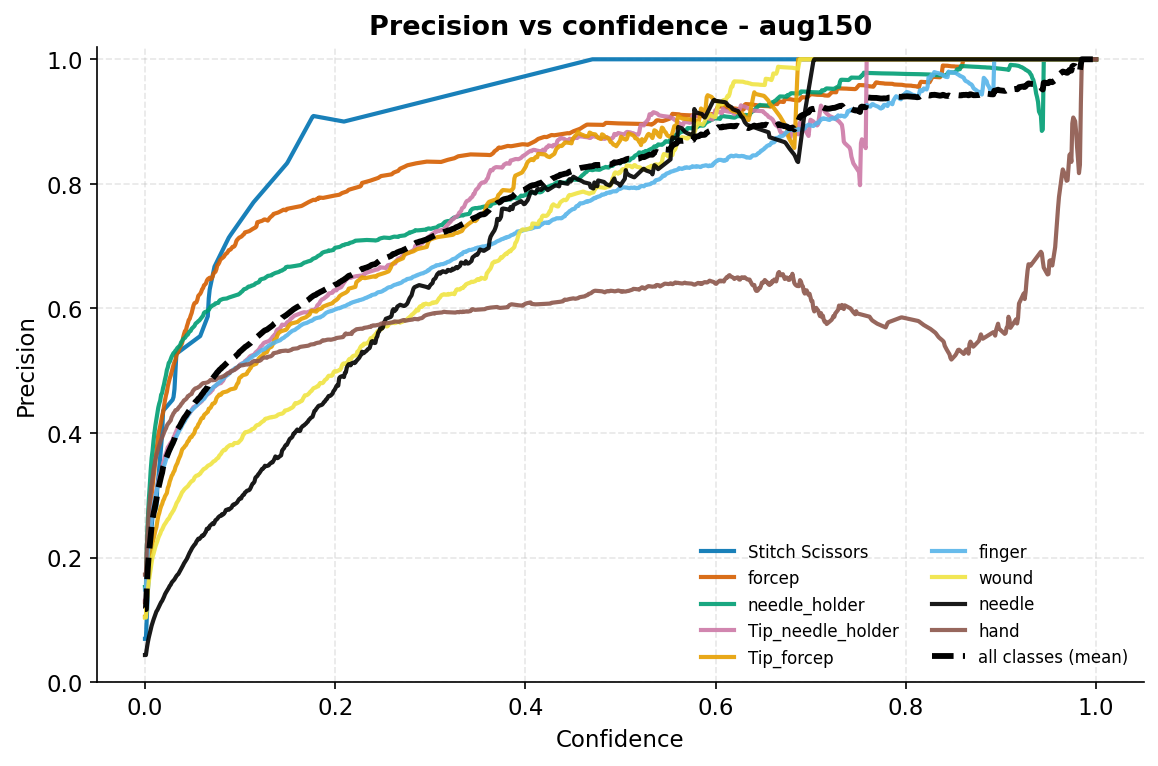

In [15]:
display(Image(filename='results_150/aug150_precision_confidence_curve.png'))

**Recall vs confidence**


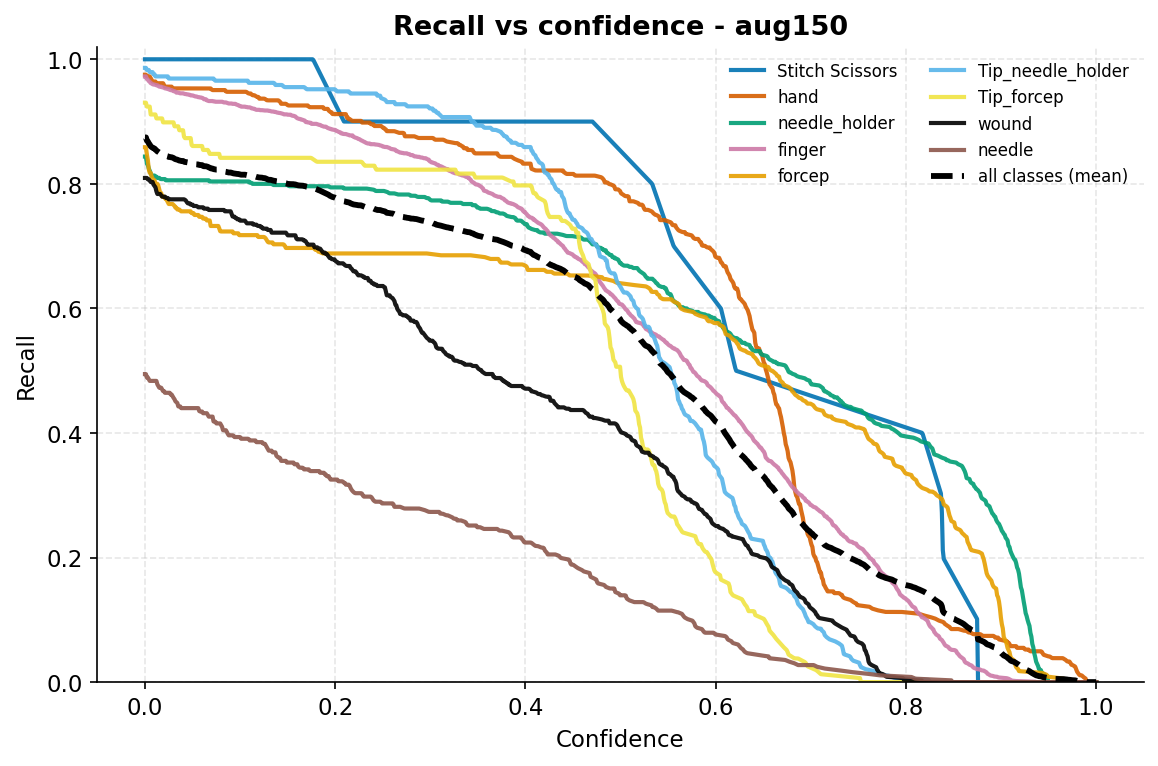

In [16]:
display(Image(filename='results_150/aug150_recall_confidence_curve.png'))

## 6. Error analysis

The easiest and hardest validation frames, ranked by false positives plus false negatives at IoU 0.5. Green solid is ground truth, orange dashed is the prediction.


**Best and worst validation frames**


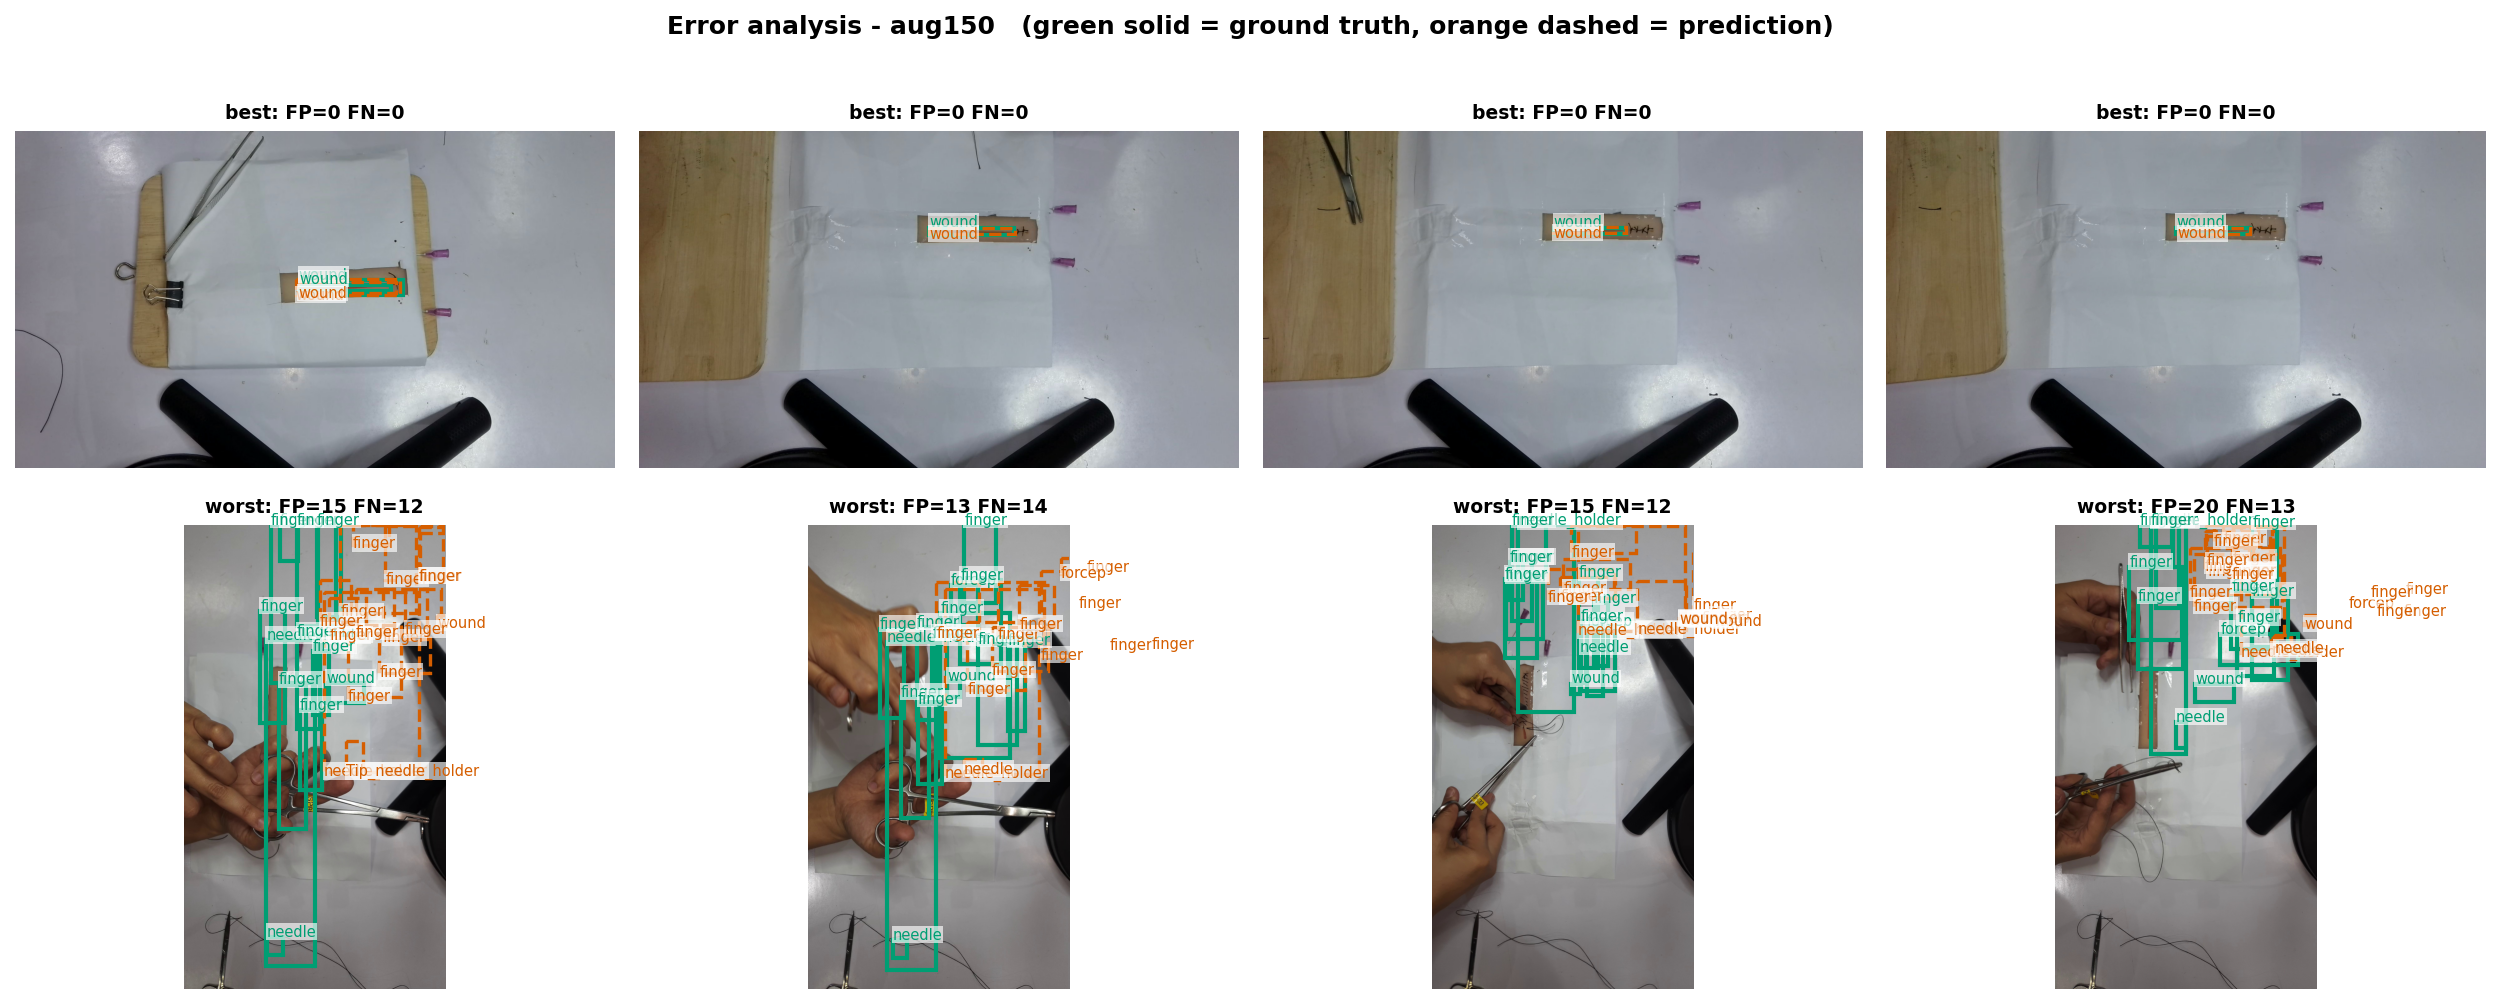

In [17]:
display(Image(filename='results_150/aug150_error_analysis_grid.png'))

## 7. Class distribution

Instances (boxes), not images: one frame routinely holds several objects, so image counts would understate the imbalance.


**Instances per class per split**


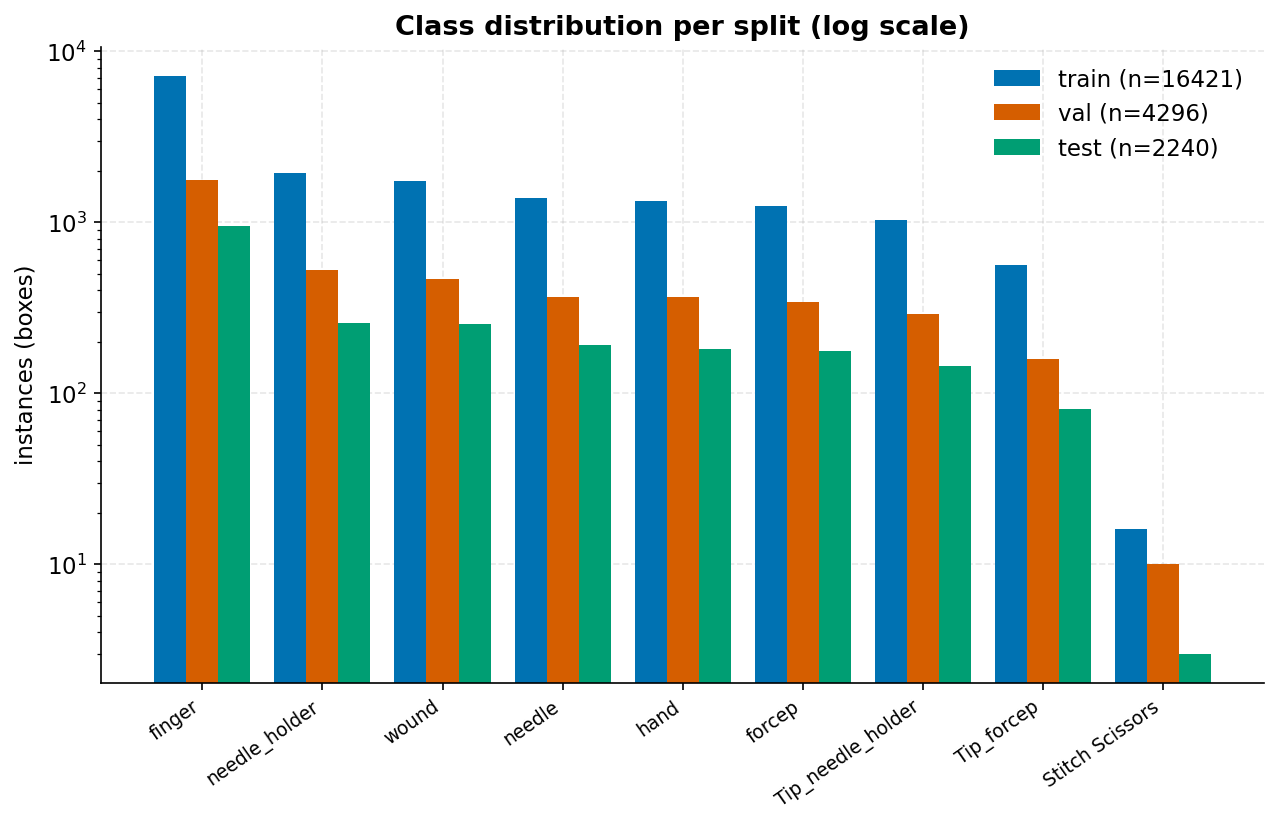

In [18]:
display(Image(filename='results_150/class_distribution.png'))